In [44]:
from pathlib import Path
import rarfile
from PIL import Image
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from sklearn.model_selection import train_test_split

In [45]:
rarfile.UNRAR_TOOL = r"D:\APP\UnRAR.exe"

DATASET_ARCHIVE=Path("../data/dataset.rar")
print(DATASET_ARCHIVE.exists())

DATASET_ROOT = Path("../data/dataset")

if not DATASET_ROOT.exists():
    DATASET_ROOT.mkdir(parents=True)

    with rarfile.RarFile(DATASET_ARCHIVE) as rar_file:
        rar_file.extractall(DATASET_ROOT)

    print("Dataset extracted.")
else:
    print("Dataset already exists. Skipping extraction.")


True
Dataset already exists. Skipping extraction.


In [46]:
items = list(DATASET_ROOT.iterdir())

for item in items:
    print(item.name)


test
train
unclean


In [47]:
train_path = DATASET_ROOT / "train"
items_in_train = list(train_path.iterdir())

for item in items_in_train:
    print(item.name)

ambulance
autobus
kamyun
kamyunet
minibus
savari
taxi
vanet


In [48]:
test_path= DATASET_ROOT / "test"
items_in_test = list(test_path.iterdir())

for item in items_in_test:
    print(item.name)

ambulance
autobus
kamyun
kamyunet
minibus
savari
taxi
vanet


In [49]:
unclean_path= DATASET_ROOT / "unclean"
items_in_unclean = list(unclean_path.iterdir())

for item in items_in_unclean:
    print(item.name)

ambulance
autobus
kamyun
kamyunet
minibus
neysan
savari
taxi
vanet


In [50]:
splits = ["train", "test", "unclean"]

for split in splits:
    split_path = DATASET_ROOT / split

    print(f"\n{split}:")

    for class_path in sorted(split_path.iterdir()):
        if class_path.is_dir():
            file_count = len([
                item for item in class_path.iterdir()
                if item.is_file()
            ])

            print(f"  {class_path.name}: {file_count}")


train:
  ambulance: 50
  autobus: 50
  kamyun: 50
  kamyunet: 50
  minibus: 50
  savari: 50
  taxi: 50
  vanet: 50

test:
  ambulance: 50
  autobus: 50
  kamyun: 50
  kamyunet: 50
  minibus: 50
  savari: 50
  taxi: 50
  vanet: 50

unclean:
  ambulance: 50
  autobus: 50
  kamyun: 50
  kamyunet: 50
  minibus: 50
  neysan: 50
  savari: 50
  taxi: 50
  vanet: 50


### Data Quality

In [51]:
splits = ["train", "test", "unclean"]

unreadable_files = []
metadata = []


for split in splits:
    split_path = DATASET_ROOT / split

    for class_path in sorted(split_path.iterdir()):
        if class_path.is_dir():
            for item in class_path.iterdir():
                if item.is_file():
                    try:
                        with Image.open(item) as img:
                            img_format = img.format
                            width, height = img.size

                        with Image.open(item) as img:
                            img.verify()

                        metadata.append({
                            "split": split,
                            "class": class_path.name,
                            "path": str(item),
                            "filename": item.name,
                            "extension": item.suffix.lower(),
                            "format": img_format,
                            "width": width,
                            "height": height,
                            "area": width * height
                        })
                    except Exception:
                        unreadable_files.append(item)

                        metadata.append({
                            "split": split,
                            "class": class_path.name,
                            "path": str(item),
                            "filename": item.name,
                            "extension": item.suffix.lower(),
                            "format": None,
                            "width": None,
                            "height": None,
                            "area": None
                        })

print(f"unreadable_files: {len(unreadable_files)}")
metadata_df = pd.DataFrame(metadata)
# print(metadata_df.head())
metadata_df

unreadable_files: 0


,split,class,path,filename,extension,format,width,height,area
0,train,ambulance,..\data\dataset\train\ambulance\198727855.jpg,198727855.jpg,.jpg,JPEG,328,365,119720
1,train,ambulance,..\data\dataset\train\ambulance\199659807.jpg,199659807.jpg,.jpg,JPEG,286,328,93808
2,train,ambulance,..\data\dataset\train\ambulance\199984667.jpg,199984667.jpg,.jpg,JPEG,269,397,106793
3,train,ambulance,..\data\dataset\train\ambulance\203158523.jpg,203158523.jpg,.jpg,JPEG,270,355,95850
4,train,ambulance,..\data\dataset\train\ambulance\203829862.jpg,203829862.jpg,.jpg,JPEG,305,353,107665
...,...,...,...,...,...,...,...,...,...
1245,unclean,vanet,..\data\dataset\unclean\vanet\217207555.jpg,217207555.jpg,.jpg,JPEG,180,240,43200
1246,unclean,vanet,..\data\dataset\unclean\vanet\217624535.jpg,217624535.jpg,.jpg,JPEG,198,243,48114
1247,unclean,vanet,..\data\dataset\unclean\vanet\217670439.jpg,217670439.jpg,.jpg,JPEG,207,265,54855
1248,unclean,vanet,..\data\dataset\unclean\vanet\218187967.jpg,218187967.jpg,.jpg,JPEG,189,252,47628


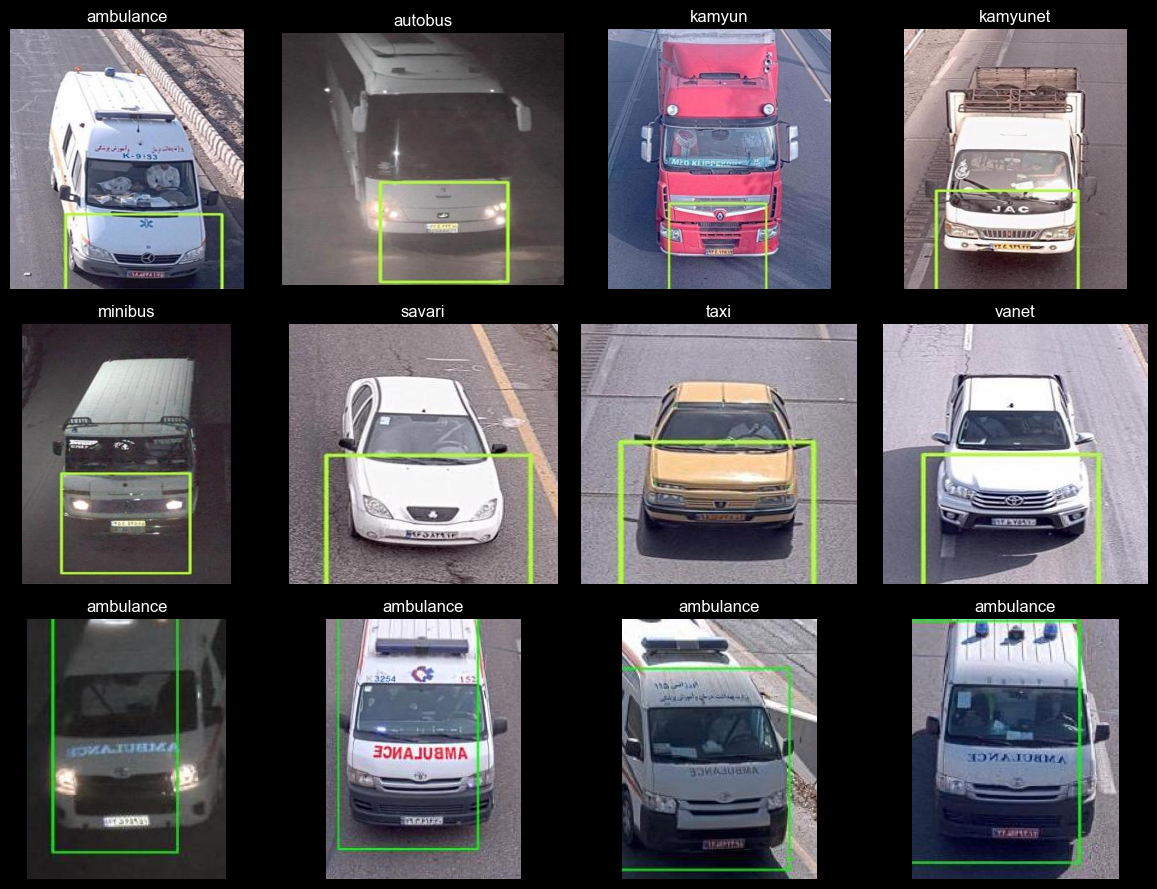

In [52]:
samples = (
    metadata_df[metadata_df["split"] == "train"]
    .groupby("class", group_keys=False)
    .head(1)
)

extra = metadata_df[metadata_df["split"] == "train"].iloc[8:12]
samples = pd.concat([samples, extra])

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img)
    ax.set_title(row["class"])
    ax.axis("off")

plt.tight_layout()
plt.show()

---
#### check images with hash md5:



In [53]:
def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

metadata_df["hash"] = metadata_df["path"].apply(file_hash)

In [54]:
duplicates = metadata_df[metadata_df["hash"].duplicated(keep=False)].sort_values("hash")
duplicates[["split", "class", "filename", "hash"]]

,split,class,filename,hash
402,test,ambulance,200396165.jpg,0964d02afe54505714ecfc869ffe8a8d
802,unclean,ambulance,200396165.jpg,0964d02afe54505714ecfc869ffe8a8d
953,unclean,kamyunet,195578789.jpg,0e2814215efe28a9d793bfa6437b3784
153,train,kamyunet,195578789.jpg,0e2814215efe28a9d793bfa6437b3784
831,unclean,ambulance,217040489.jpg,152bc5c80a73ba5ba5a6c81e283d6dec
424,test,ambulance,217040489.jpg,152bc5c80a73ba5ba5a6c81e283d6dec
44,train,ambulance,218591595.jpg,16ae5af2c0d39b286681718d45d04eeb
842,unclean,ambulance,218591595.jpg,16ae5af2c0d39b286681718d45d04eeb
9,train,ambulance,213342200.jpg,278746eb592f64791fe0f0b3668ce317
811,unclean,ambulance,213342200.jpg,278746eb592f64791fe0f0b3668ce317


In [55]:
duplicates.groupby("hash")["class"].nunique().value_counts()

class
1    23
2     1
Name: count, dtype: int64

In [56]:
conflict_hashes = (
    metadata_df.groupby("hash")["class"].nunique()
)
conflict_hashes = conflict_hashes[conflict_hashes > 1]
print(conflict_hashes)

hash
ef3cab770c805c85aa9b94f05499e0ee    2
Name: class, dtype: int64


In [57]:
metadata_df[metadata_df["hash"] == "ef3cab770c805c85aa9b94f05499e0ee"]

,split,class,path,filename,extension,format,width,height,area,hash
383,train,vanet,..\data\dataset\train\vanet\214844236.jpg,214844236.jpg,.jpg,JPEG,156,204,31824,ef3cab770c805c85aa9b94f05499e0ee
1085,unclean,neysan,..\data\dataset\unclean\neysan\214844236.jpg,214844236.jpg,.jpg,JPEG,156,204,31824,ef3cab770c805c85aa9b94f05499e0ee


In [58]:
metadata_df.groupby(["split", "class"]).size()

split    class    
test     ambulance    50
         autobus      50
         kamyun       50
         kamyunet     50
         minibus      50
         savari       50
         taxi         50
         vanet        50
train    ambulance    50
         autobus      50
         kamyun       50
         kamyunet     50
         minibus      50
         savari       50
         taxi         50
         vanet        50
unclean  ambulance    50
         autobus      50
         kamyun       50
         kamyunet     50
         minibus      50
         neysan       50
         savari       50
         taxi         50
         vanet        50
dtype: int64

In [65]:
clean_train_df = metadata_df[metadata_df["split"] == "train"]

train_df , val_df = train_test_split(clean_train_df, test_size=0.2,stratify=clean_train_df["class"],random_state=42)
test_df = metadata_df[metadata_df["split"] == "test"]

In [66]:
print(train_df["class"].value_counts())
print(val_df["class"].value_counts())
print(test_df["class"].value_counts())


class
kamyunet     40
minibus      40
autobus      40
savari       40
kamyun       40
taxi         40
vanet        40
ambulance    40
Name: count, dtype: int64
class
savari       10
minibus      10
kamyun       10
kamyunet     10
vanet        10
taxi         10
autobus      10
ambulance    10
Name: count, dtype: int64
class
ambulance    50
autobus      50
kamyun       50
kamyunet     50
minibus      50
savari       50
taxi         50
vanet        50
Name: count, dtype: int64


In [67]:
Path("../csv_files").mkdir(parents=True, exist_ok=True)

train_df.to_csv("../csv_files/train_split.csv", index=False)
val_df.to_csv("../csv_files/val_split.csv", index=False)
test_df.to_csv("../csv_files/test_split.csv", index=False)